# 17. Dataset para refinamiento de profundidad

Este notebook prepara la nueva línea experimental dedicada al refinamiento de profundidad. El objetivo no es sustituir la pipeline principal, sino generar pares supervisados que permitan entrenar una red capaz de corregir la salida inicial de Depth Pro.

En este planteamiento, la entrada del modelo es el mapa de profundidad estimado por Depth Pro. Como referencia supervisada se utiliza un mapa de profundidad sparse, obtenido al proyectar el sensor `LIDAR_TOP` sobre cada cámara mediante las calibraciones de nuScenes.

Además, se genera una máscara binaria que indica los píxeles para los que existe una profundidad LiDAR válida. Esta máscara permite restringir el cálculo de la pérdida únicamente a las zonas con supervisión disponible.

In [ ]:
from pathlib import Path
import json
import os
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

MANIFEST = ROOT / 'manifests' / 'scene-0061_first30.json'
FULL_OUTPUT_DIR = ROOT / 'outputs' / 'scene-0061' / 'depth_refinement_dataset_first30'
LEGACY_OUTPUT_DIR = ROOT / 'outputs' / 'scene-0061' / 'depth_refinement_dataset'
SMOKE_OUTPUT_DIR = ROOT / 'outputs' / 'scene-0061' / 'depth_refinement_dataset_front_smoke'

RUN_DATASET_GENERATION = False
RUN_SMOKE_GENERATION = False
OVERWRITE_EXISTING_DATASET = False

OUTPUT_DIR = FULL_OUTPUT_DIR if (FULL_OUTPUT_DIR / 'dataset_index.json').exists() else (LEGACY_OUTPUT_DIR if (LEGACY_OUTPUT_DIR / 'dataset_index.json').exists() else SMOKE_OUTPUT_DIR)
INDEX_PATH = OUTPUT_DIR / 'dataset_index.json'
DEPTH_PRO_ROOT = Path(os.environ.get('DEPTH_PRO_ROOT', ROOT.parent))

print('Python kernel:', sys.executable)
print('ROOT:', ROOT)
print('Dataset de visualizacion:', OUTPUT_DIR)
print('Dataset completo first30:', FULL_OUTPUT_DIR)
print('Dataset legacy first5:', LEGACY_OUTPUT_DIR)
print('Dataset smoke:', SMOKE_OUTPUT_DIR)
print('Depth Pro root:', DEPTH_PRO_ROOT)
print('RUN_DATASET_GENERATION:', RUN_DATASET_GENERATION)
print('RUN_SMOKE_GENERATION:', RUN_SMOKE_GENERATION)
print('OVERWRITE_EXISTING_DATASET:', OVERWRITE_EXISTING_DATASET)

Python kernel: /home/clara/ml-depth-pro/depthpro_env/bin/python
ROOT: /home/clara/ml-depth-pro/slam_readiness_nuscenes
Dataset de visualizacion: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30
Dataset completo first30: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30
Dataset legacy first5: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset
Dataset smoke: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_front_smoke
Depth Pro root: /home/clara/ml-depth-pro
RUN_DATASET_GENERATION: False
RUN_SMOKE_GENERATION: False
OVERWRITE_EXISTING_DATASET: False


## 1. Generación del dataset

La siguiente celda se encarga de generar el dataset, o bien de reconstruir su índice, directamente desde el notebook. Los parámetros principales se definen en la primera celda mediante los flags `RUN_DATASET_GENERATION`, `RUN_SMOKE_GENERATION` y `OVERWRITE_EXISTING_DATASET`.

Cuando los ficheros `.npz` ya existen y `OVERWRITE_EXISTING_DATASET = False`, no se vuelve a ejecutar Depth Pro. En ese caso, el proceso únicamente reconstruye el fichero `dataset_index.json` a partir de los datos ya generados. Para forzar una generación completa de los mapas de profundidad, es necesario establecer `OVERWRITE_EXISTING_DATASET = True`.

In [2]:
dataset_cmd = [
    sys.executable,
    str(ROOT / 'scripts' / 'prepare_depth_refinement_dataset.py'),
    '--manifest', str(MANIFEST),
    '--depth-pro-root', str(DEPTH_PRO_ROOT),
    '--output-dir', str(FULL_OUTPUT_DIR),
    '--max-width', '640',
]
if OVERWRITE_EXISTING_DATASET:
    dataset_cmd.append('--overwrite')

print(' '.join(dataset_cmd))

if RUN_DATASET_GENERATION:
    subprocess.run(dataset_cmd, cwd=str(ROOT), check=True)
else:
    print('No se ha ejecutado. Cambia RUN_DATASET_GENERATION a True para generar o reindexar el dataset.')

/home/clara/ml-depth-pro/depthpro_env/bin/python /home/clara/ml-depth-pro/slam_readiness_nuscenes/scripts/prepare_depth_refinement_dataset.py --manifest /home/clara/ml-depth-pro/slam_readiness_nuscenes/manifests/scene-0061_first30.json --depth-pro-root /home/clara/ml-depth-pro --output-dir /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30 --max-width 640
No se ha ejecutado. Cambia RUN_DATASET_GENERATION a True para generar o reindexar el dataset.


Para una prueba rapida se puede generar solo `CAM_FRONT` y pocos samples. Esta celda tambien se puede ejecutar desde el notebook cambiando `RUN_SMOKE_GENERATION = True` en la primera celda.

In [3]:
smoke_cmd = [
    sys.executable,
    str(ROOT / 'scripts' / 'prepare_depth_refinement_dataset.py'),
    '--manifest', str(MANIFEST),
    '--depth-pro-root', str(DEPTH_PRO_ROOT),
    '--output-dir', str(SMOKE_OUTPUT_DIR),
    '--max-samples', '1',
    '--channels', 'CAM_FRONT',
    '--max-width', '320',
]
if OVERWRITE_EXISTING_DATASET:
    smoke_cmd.append('--overwrite')

print(' '.join(smoke_cmd))

if RUN_SMOKE_GENERATION:
    subprocess.run(smoke_cmd, cwd=str(ROOT), check=True)
else:
    print('No se ha ejecutado. Cambia RUN_SMOKE_GENERATION a True para una prueba rapida.')

/home/clara/ml-depth-pro/depthpro_env/bin/python /home/clara/ml-depth-pro/slam_readiness_nuscenes/scripts/prepare_depth_refinement_dataset.py --manifest /home/clara/ml-depth-pro/slam_readiness_nuscenes/manifests/scene-0061_first30.json --depth-pro-root /home/clara/ml-depth-pro --output-dir /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_front_smoke --max-samples 1 --channels CAM_FRONT --max-width 320
No se ha ejecutado. Cambia RUN_SMOKE_GENERATION a True para una prueba rapida.


## 2. Inspeccion del dataset generado

Cuando el script haya generado `dataset_index.json`, esta seccion resume cuantos pares hay, que camaras se han procesado y cuantos pixeles LiDAR validos aparecen por imagen.

In [4]:
if not INDEX_PATH.exists():
    print('Todavia no existe:', INDEX_PATH)
    print('Ejecuta primero el comando de generacion del dataset.')
else:
    index = json.loads(INDEX_PATH.read_text(encoding='utf-8-sig'))
    entries = pd.DataFrame(index['entries'])
    print('Entradas:', len(entries))
    display(entries[['sample_index', 'channel', 'width', 'height', 'valid_lidar_pixels', 'valid_lidar_ratio', 'gt_depth_median_valid']].head())
    display(entries.groupby('channel')[['valid_lidar_pixels', 'valid_lidar_ratio']].mean())

Entradas: 180


,sample_index,channel,width,height,valid_lidar_pixels,valid_lidar_ratio,gt_depth_median_valid
0,0,CAM_FRONT_LEFT,640,360,3698,0.016050,12.070423
1,0,CAM_FRONT,640,360,3045,0.013216,10.311219
2,0,CAM_FRONT_RIGHT,640,360,3070,0.013325,13.769853
3,0,CAM_BACK_RIGHT,640,360,3327,0.014440,15.795471
4,0,CAM_BACK,640,360,4784,0.020764,10.058857


,valid_lidar_pixels,valid_lidar_ratio
channel,,
CAM_BACK,4448.400000,0.019307
CAM_BACK_LEFT,4076.333333,0.017692
CAM_BACK_RIGHT,3359.833333,0.014583
CAM_FRONT,3031.100000,0.013156
CAM_FRONT_LEFT,3428.166667,0.014879
CAM_FRONT_RIGHT,3185.333333,0.013825


## 3. Visualizacion de mapas de profundidad

Esta seccion muestra de forma directa los mapas que forman cada par de entrenamiento: la profundidad de entrada producida por Depth Pro, la etiqueta sparse generada desde `LIDAR_TOP` y la mascara de pixeles validos.

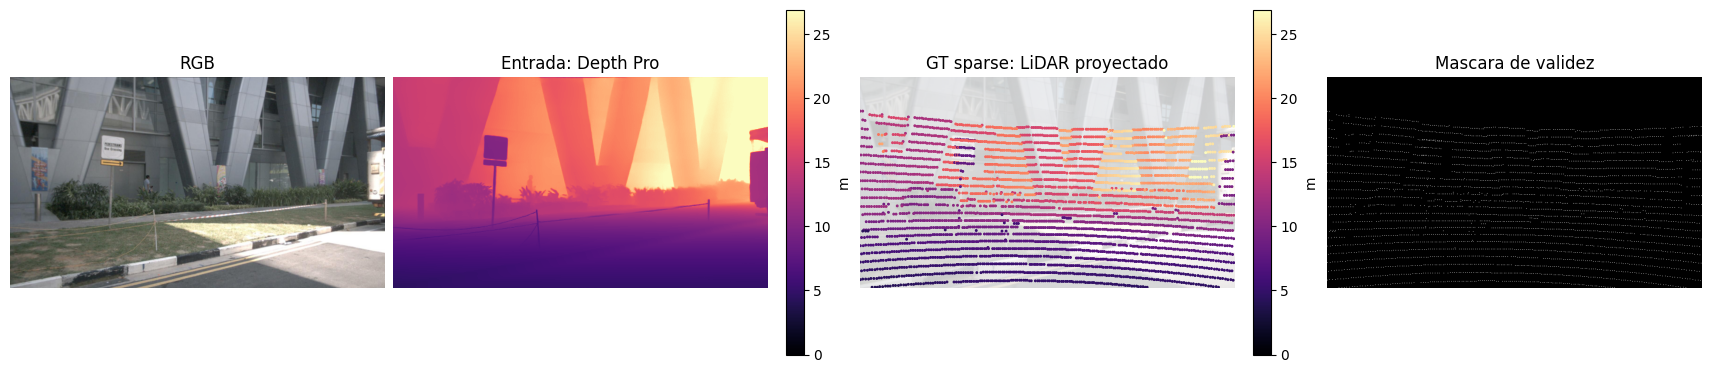

Entrada visualizada: 0 CAM_FRONT_LEFT
Pixeles LiDAR validos: 3698
Ratio valido: 0.016050347222222223


In [5]:
if not INDEX_PATH.exists():
    print('No hay dataset generado todavia.')
else:
    index = json.loads(INDEX_PATH.read_text(encoding='utf-8-sig'))
    entry = index['entries'][0]
    data = np.load(OUTPUT_DIR / entry['npz_path'])

    rgb = data['rgb']
    depth_pro = data['depth_pro'].astype(np.float32)
    gt_depth = data['gt_depth'].astype(np.float32)
    valid_mask = data['valid_mask'].astype(bool)

    gt_sparse = np.where(valid_mask, gt_depth, np.nan)
    valid_values = gt_depth[valid_mask]
    depth_values = depth_pro[np.isfinite(depth_pro)]
    all_values = np.concatenate([depth_values, valid_values]) if valid_values.size else depth_values
    vmax = float(np.nanpercentile(all_values, 95)) if all_values.size else 50.0
    vmax = max(vmax, 1.0)

    depth_cmap = plt.cm.magma.copy()
    sparse_cmap = plt.cm.magma.copy()
    sparse_cmap.set_bad(color='white')

    fig, axes = plt.subplots(1, 4, figsize=(17, 4), constrained_layout=True)
    axes[0].imshow(rgb)
    axes[0].set_title('RGB')

    im1 = axes[1].imshow(np.clip(depth_pro, 0, vmax), cmap=depth_cmap, vmin=0, vmax=vmax)
    axes[1].set_title('Entrada: Depth Pro')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, label='m')

    axes[2].imshow(rgb, alpha=0.25)
    ys, xs = np.where(valid_mask)
    sc = axes[2].scatter(xs, ys, c=gt_depth[ys, xs], s=1.2, cmap=sparse_cmap, vmin=0, vmax=vmax)
    axes[2].set_title('GT sparse: LiDAR proyectado')
    fig.colorbar(sc, ax=axes[2], fraction=0.046, label='m')

    axes[3].imshow(valid_mask, cmap='gray')
    axes[3].set_title('Mascara de validez')

    for ax in axes:
        ax.axis('off')
    plt.show()

    print('Entrada visualizada:', entry['sample_index'], entry['channel'])
    print('Pixeles LiDAR validos:', int(valid_mask.sum()))
    print('Ratio valido:', float(valid_mask.mean()))

## 4. Overlay de la etiqueta LiDAR sobre la imagen

En esta celda se visualiza, para una misma muestra, la imagen RGB, el mapa de profundidad generado por Depth Pro y los puntos LiDAR proyectados sobre la cámara correspondiente.

Esta comparación permite revisar de forma visual si las calibraciones y la proyección entre sensores son coherentes. En particular, el overlay de los puntos LiDAR sobre la imagen facilita detectar posibles desalineamientos, errores de transformación o problemas en la asociación entre cámara y nube de puntos.

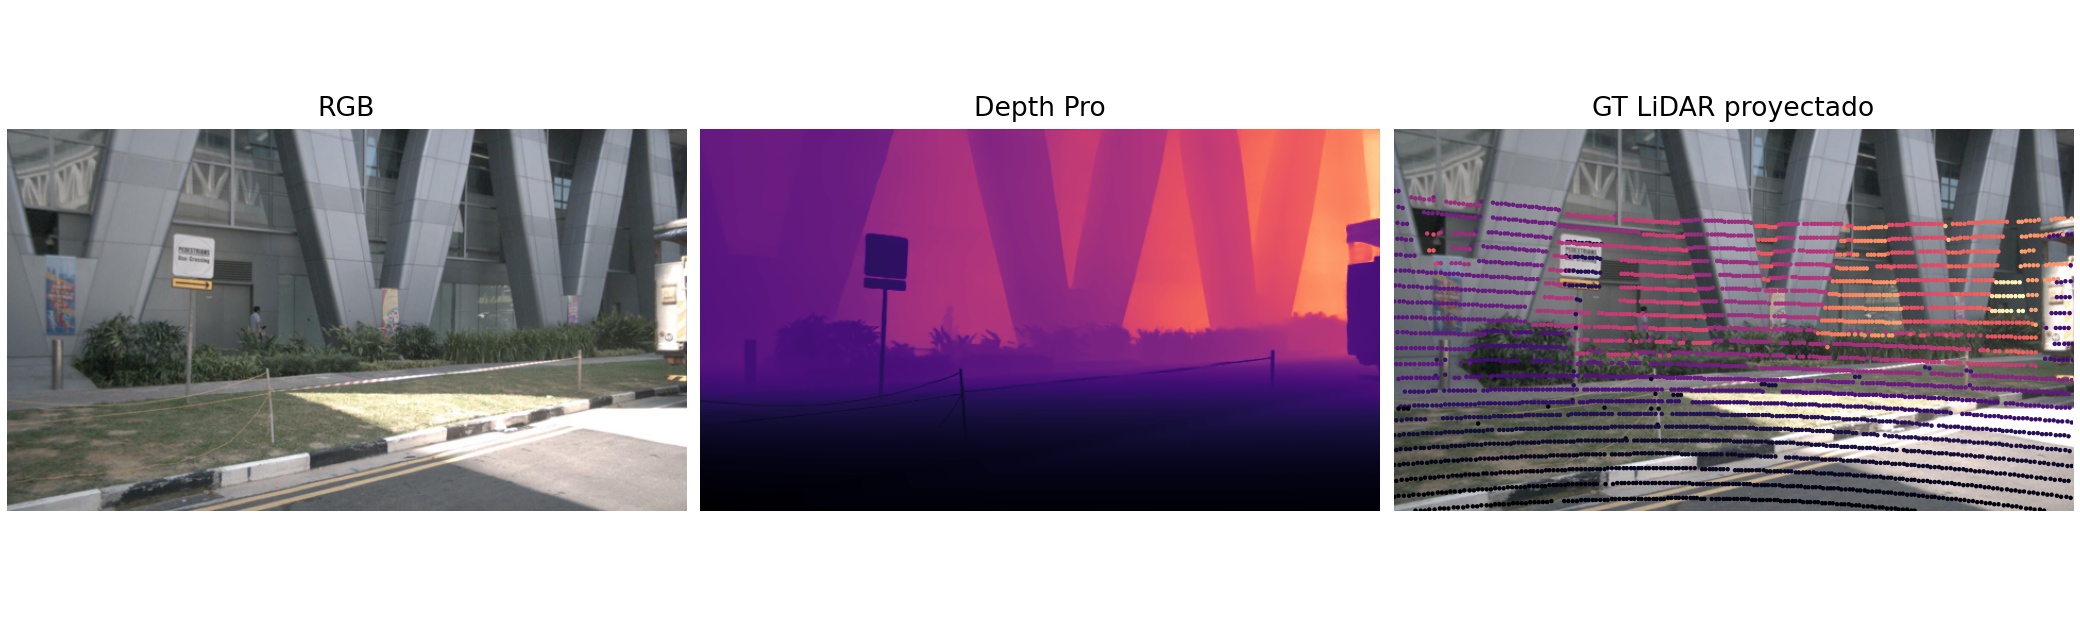

In [6]:
if INDEX_PATH.exists():
    index = json.loads(INDEX_PATH.read_text(encoding='utf-8-sig'))
    preview_entries = [e for e in index['entries'] if 'preview_path' in e]
    if preview_entries:
        preview_path = OUTPUT_DIR / preview_entries[0]['preview_path']
        display(Image(filename=str(preview_path)))
    else:
        print('No hay previews guardadas. Reejecuta el script con --preview-limit mayor que 0.')
else:
    print('No hay dataset generado todavia.')

## 5. Lectura esperada

Este dataset no proporciona un ground truth denso. La etiqueta de profundidad se obtiene a partir del LiDAR proyectado sobre la imagen, por lo que solo una parte de los píxeles dispone de una profundidad válida.

Por este motivo, en el entrenamiento posterior es necesario utilizar `valid_mask` y calcular la función de pérdida únicamente sobre los píxeles con supervisión LiDAR disponible.

Si la proyección se ha realizado correctamente, los puntos LiDAR deberían situarse sobre superficies visibles de la imagen. En caso de observar desplazamientos claros o patrones incoherentes, habría que revisar posibles errores en los intrínsecos, los extrínsecos, la sincronización entre sensores o el escalado aplicado a la imagen.